In [2]:
from dateutil.parser import parse 
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
plt.rcParams.update({'figure.figsize': (10, 7), 'figure.dpi': 120})

from statsmodels.tsa.seasonal import seasonal_decompose
from dateutil.parser import parse

import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller, kpss

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split


from scipy.stats import norm
import statsmodels.api as sm
from datetime import datetime

from math import sqrt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) 

In [6]:
# dataset source: https://github.com/rouseguy
df = pd.read_csv('C://Users/crisr/Documents/ASN_Rocks/Series_Temporais/2. Curso_Completo/Dados/gas.txt', header=None)
df.head(10)

,0
0,100.0
1,100.0
2,101.1
3,103.4
4,105.7
5,108.6
6,110.4
7,111.1
8,110.9
9,112.9


In [3]:
################################
################################
#1. Visualizando a série temporal

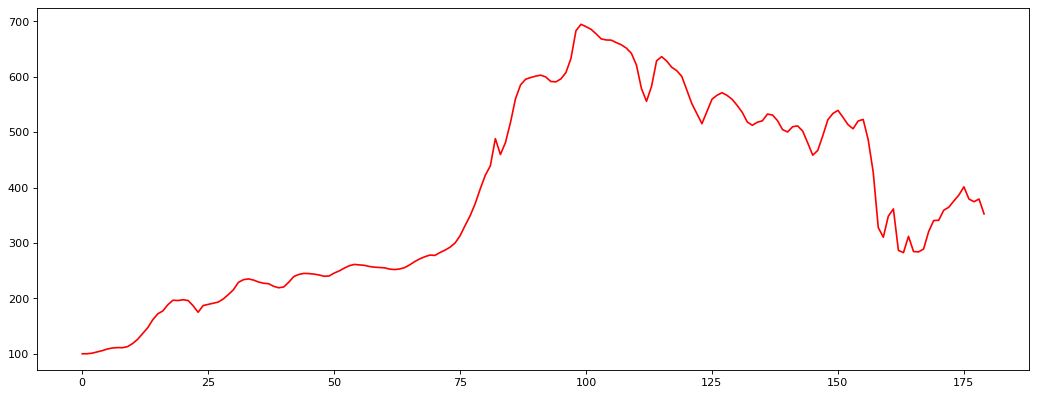

In [4]:
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df, color='red')

In [5]:
################################
################################
#2. Verificando se a série é um Ruído Branco
#Usando Teste Ljung-Box

In [6]:
sm.stats.acorr_ljungbox(df, lags=[5], return_df=True)

,lb_stat,lb_pvalue
5,837.92815,7.201070e-179


p_valor < nível_significancia  => rejeitar a hipotese nula => série não é ruído branco

In [7]:
################################
################################
#3. Verificando se a série é Estacionária
# ADF test 
#ADF test, where the null hypothesis is the time series possesses a unit root and is non-stationary. 
#So, id the P-Value in ADH test is less than the significance level (0.05), you reject the null hypothesis.
result = adfuller(df, autolag='AIC')
print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')

ADF Statistic: -1.6686949688089765
p-value: 0.44730962993059564


p_valor > nível_significancia  => não rejeita a hipotese nula => série não é estacionaria

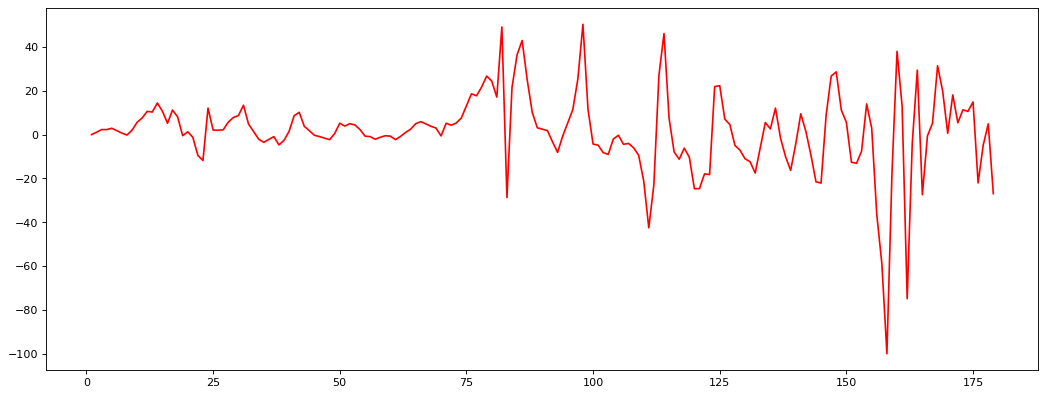

In [4]:
################################
################################
#4. Aplicando uma diferenciação para tornar a serie estacionáriaa
df_diff = df.diff()
fig  = plt.subplots(1, figsize=(16,6), dpi= 80)
plt.plot(df_diff, color='red')

In [5]:
df_diff.head(5)

,0
0,NaN
1,0.0
2,1.1
3,2.3
4,2.3


In [12]:
#df.head(5)

In [13]:
# verificar se a serie diferenciada é estacionária
teste = adfuller(df_diff.dropna(), autolag='AIC')
print(f'ADF Statistic: {teste[0]}')
print(f'p-value: {teste[1]}')

ADF Statistic: -6.33750977151173
p-value: 2.8069575587184566e-08


p_valor < nível_significancia =>  rejeita a hipotese nula => série  é estacionaria

In [ ]:
################################
################################
#5. IDENTIFICAÇÃO
# Verificando autocorrelação e autocorrelação parcial

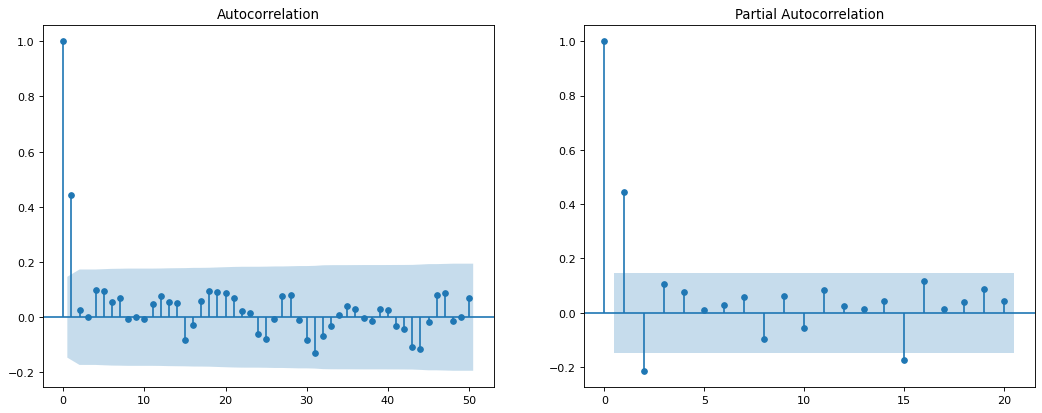

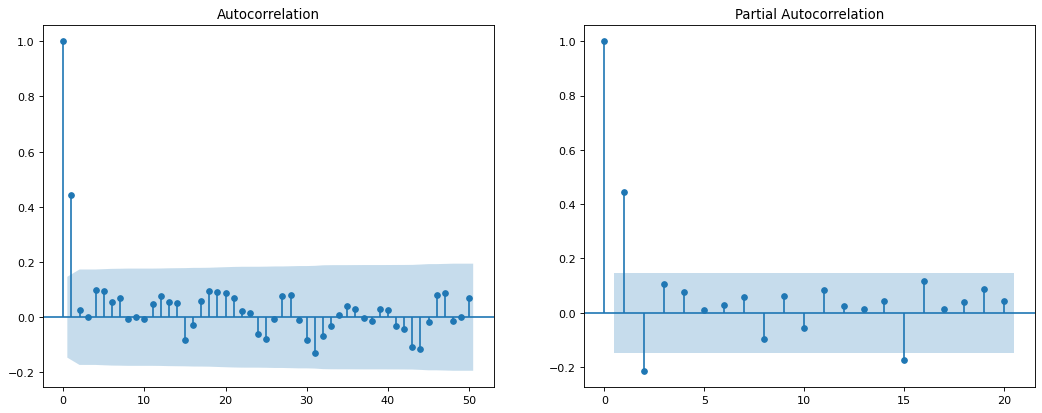

In [14]:
df_diff_1 = df_diff.dropna()
fig, (ax1, ax2) = plt.subplots(1, 2,figsize=(16,6), dpi= 80)
plot_acf(df_diff_1, ax=ax1, lags=50)
plot_pacf(df_diff_1, ax=ax2, lags=20)

Vou testar num primeiro momento um ARIMA(2,1,1)

In [16]:
################################
################################
# 5. ESTIMAÇÃO
# Ajusta o modelo

In [17]:
model = sm.tsa.statespace.SARIMAX(df, order=(2,1,1))
results_ARIMA = model.fit()  
# summary of fit model
print(results_ARIMA.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                  180
Model:               SARIMAX(2, 1, 1)   Log Likelihood                -745.968
Date:                Mon, 06 Nov 2023   AIC                           1499.935
Time:                        21:59:16   BIC                           1512.685
Sample:                             0   HQIC                          1505.105
                                - 180                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2929      0.196      1.497      0.134      -0.091       0.676
ar.L2         -0.1052      0.104     -1.008      0.314      -0.310       0.099
ma.L1          0.2742      0.201      1.365      0.1

In [18]:
y_true = df.values
y_pred = results_ARIMA.fittedvalues
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print('R2:   %.3f' % r2)
print('MSE:  %.3f' % mse)
print('RMSE: %.3f' % rmse)
print('MAE:  %.3f' % mae)
print('MAPE: %.3f' % mape)

R2:   0.990
MSE:  297.686
RMSE: 17.254
MAE:  9.961
MAPE: 0.694


In [19]:
# vou primeiro remover a parte AR(2) que tem o maior p_valor
model1 = sm.tsa.statespace.SARIMAX(df, order=(1,1,1))
results_ARIMA1 = model1.fit()  
# summary of fit model
print(results_ARIMA1.summary())

                               SARIMAX Results                                
Dep. Variable:                      0   No. Observations:                  180
Model:               SARIMAX(1, 1, 1)   Log Likelihood                -746.227
Date:                Mon, 06 Nov 2023   AIC                           1498.454
Time:                        21:59:16   BIC                           1508.017
Sample:                             0   HQIC                          1502.332
                                - 180                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1408      0.082      1.708      0.088      -0.021       0.302
ma.L1          0.4218      0.083      5.070      0.000       0.259       0.585
sigma2       244.1984     12.793     19.088      0.0

In [20]:
y_true = df.values
y_pred = results_ARIMA1.fittedvalues
r2   = r2_score(y_true, y_pred)
mse  = mean_squared_error(y_true, y_pred)
rmse = sqrt(mean_squared_error(y_true, y_pred))
mae  = mean_absolute_error(y_true, y_pred)
mape = mean_absolute_percentage_error(y_true, y_pred)

print('R2:   %.3f' % r2)
print('MSE:  %.3f' % mse)
print('RMSE: %.3f' % rmse)
print('MAE:  %.3f' % mae)
print('MAPE: %.3f' % mape)

R2:   0.990
MSE:  298.404
RMSE: 17.274
MAE:  9.903
MAPE: 0.694


Todos os parametros são significantes e o AIC ficou menor

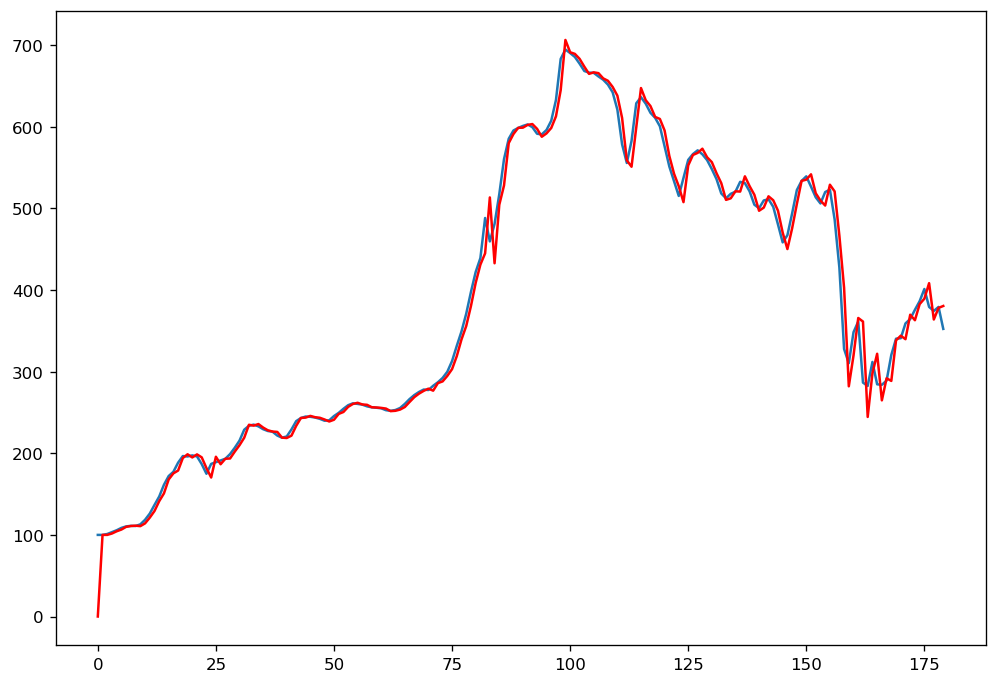

In [21]:
plt.plot(df)
plt.plot(results_ARIMA1.fittedvalues,  color='red')

In [ ]:
################################
################################
# 6. VERIFICAÇÃO
# Avalia a qualidade do ajuste 

In [22]:
# Aplicando teste do ruido branco do resíduo
sm.stats.acorr_ljungbox(results_ARIMA1.resid, lags=[10], return_df=True)

,lb_stat,lb_pvalue
10,3.997432,0.947463


In [ ]:
## Analisa também o residuo para verificar se satisfaz as condições de ruido branco
## line plot of residuals
#residuals = results_ARIMA1.resid
#residuals.plot()
#pyplot.show()
## density plot of residuals
#residuals.plot(kind='kde')
#pyplot.show()
## summary stats of residuals
#print(residuals.describe())

In [23]:
################################
################################
# 6. PREVISÃO
predictions = results_ARIMA1.forecast(30)

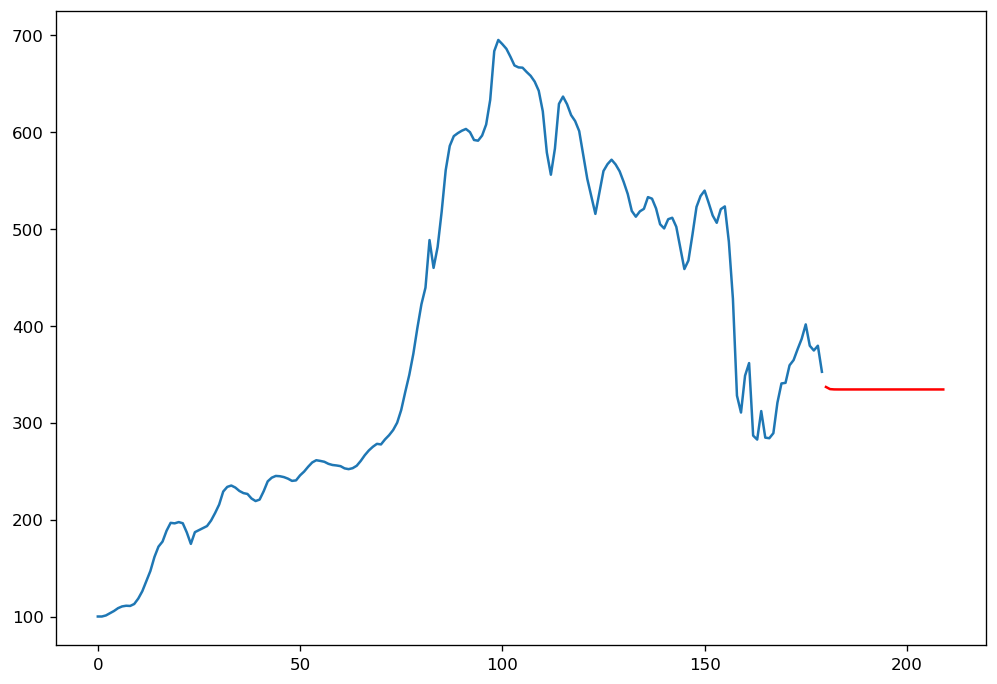

In [24]:
# plot forecasts against actual outcomes
pyplot.plot(df)
pyplot.plot(predictions, color='red')
pyplot.show()